In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge


In [233]:
def draw_hist(y_pred, y_val):
    sns.histplot(y_pred, label = 'prediction')
    sns.histplot(y_val, label = 'target')
    plt.legend()
    plt.show()

In [234]:
df = pd.read_csv('ds/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [235]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
string_columns = list(df.dtypes[df.dtypes == 'str'].index)
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [236]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,clean_&_quiet_apt_home_by_the_park,2787,john,brooklyn,kensington,40.64749,-73.97237,private_room,149,1,9,2018-10-19,0.21,6,365
1,2595,skylit_midtown_castle,2845,jennifer,manhattan,midtown,40.75362,-73.98377,entire_home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,the_village_of_harlem....new_york_!,4632,elisabeth,manhattan,harlem,40.80902,-73.94190,private_room,150,3,0,NaN,NaN,1,365
3,3831,cozy_entire_floor_of_brownstone,4869,lisaroxanne,brooklyn,clinton_hill,40.68514,-73.95976,entire_home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,entire_apt:_spacious_studio/loft_by_central_park,7192,laura,manhattan,east_harlem,40.79851,-73.94399,entire_home/apt,80,10,9,2018-11-19,0.10,1,0


In [237]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [238]:
base = ['room_type', 'minimum_nights', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'number_of_reviews']
num_base = ['latitude', 'longitude', 'minimum_nights', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews', 'availability_365']
str_base = ['room_type', 'neighbourhood_group', 'neighbourhood']

In [239]:
df = df.fillna(df['reviews_per_month'].mean())
df_dummies = pd.get_dummies(df[str_base])
df = pd.concat([df[num_base], df_dummies, df[['price']]], axis=1)

In [240]:
n = len(df)
print(n)

48895


In [241]:
n_train = int(n * 0.6)
n_val = int(0.2 * n)
n_test = int(0.2 * n)

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
df_shuffled = df.iloc[idx]

feature_cols = [col for col in df.columns if col != 'price']

X_train = df_shuffled[feature_cols][:n_train].values
X_val = df_shuffled[feature_cols][n_train:n_train + n_val].values
X_test = df_shuffled[feature_cols][n_train + n_val:].values


y_train = np.log1p(df_shuffled[:n_train].price.values)
y_val = np.log1p(df_shuffled[n_train:n_train + n_val].price.values)
y_test = np.log1p(df_shuffled[n_train + n_val:].price.values)

In [242]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

In [243]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

print('val:', rmse(y_val, y_pred))

val: 0.47070628129398345


In [244]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print('train:', rmse(y_train, y_train_pred))
print('val:  ', rmse(y_val, y_pred))
print('test:', rmse(y_test, y_test_pred))

train: 0.4666001806420428
val:   0.47070628129398345
test: 0.489794384672976


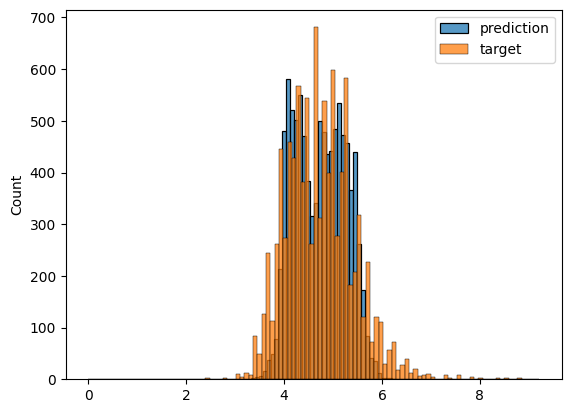

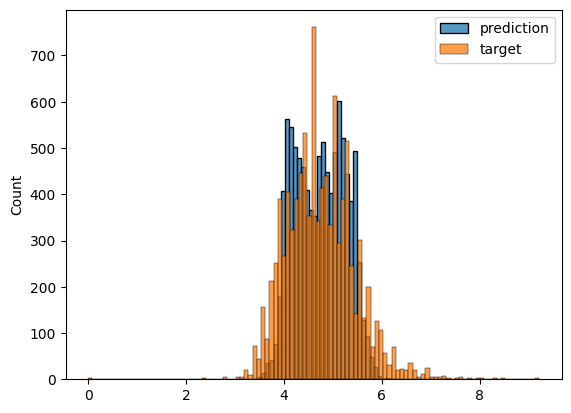

In [245]:
draw_hist(y_pred, y_val)
draw_hist(y_test_pred, y_test)

In [246]:
for alpha in [0, 0.001, 0.01, 0.1, 1, 10]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    print(alpha, ' : ', rmse(y_val, y_pred))

0  :  3488539028.1031
0.001  :  0.47070301027401296
0.01  :  0.4706740798951806
0.1  :  0.47042848217104916
1  :  0.469629367363828
10  :  0.4694895126255917


In [ ]:
#Ridge не дает особо прироста, на этих данных это потолок для этой модели

In [249]:
#Тест
# Ожидаемые цены (ориентировочно):
# - 1: ~$200+ (Manhattan, entire home, Midtown)
# - 2: ~$100-150 (Brooklyn, entire home, но дальше от центра)
# - 3: ~$80-120 (Manhattan, private room, Harlem)

test_data = pd.DataFrame({
    'latitude': [40.7580, 40.6851, 40.8176],
    'longitude': [-73.9855, -73.9598, -73.9419],
    'minimum_nights': [1, 2, 5],
    'reviews_per_month': [0.38, 4.64, 1.20],
    'calculated_host_listings_count': [2, 1, 3],
    'number_of_reviews': [45, 270, 30],
    'availability_365': [355, 194, 120],
    'room_type': ['entire_home/apt', 'entire_home/apt', 'private_room'],
    'neighbourhood_group': ['manhattan', 'brooklyn', 'manhattan'],
    'neighbourhood': ['midtown', 'clinton_hill', 'harlem']
})


test_dummies = pd.get_dummies(test_data[str_base])
test_processed = pd.concat([test_data[num_base], test_dummies], axis=1)

test_processed = test_processed.reindex(columns=feature_cols, fill_value=0)

y_pred = np.expm1(model.predict(test_processed.values))
print('Prices:', [f'${p:.0f}' for p in y_pred])


Prices: ['$321', '$146', '$72']
